- 출처 : 금융 파이썬 쿡북
# 머신러닝으로 디폴트 찾기

* 사용되는 데이터 셋은 2005년 10월 대만 은행에서 수집 
* 이 연구는 그 당시 점점 더 많은 은행들이 기꺼이 고객들에게 현금 및 신용카드을 발급하고 있는 사실에서 비롯되었다. 
* 상환 능력에 관계없이 점점 더 많은 사람들이 상당한 양의 부채를 축적해 결국 디폴트를 초래했음 
* 당시 연구 목표는 과거 상환 내역과 함께 고객에 대한 몇 가지 기본정보(성별, 연령, 교육 수준)를 사용해 디폴트 가능성이 높은 사람을 예측하는 것 
* 6개월의 상환내역(2005년 4월 ~ 9월)을 사용해 고객이 2005년 10월에 디폴트를 할지 여부를 예측하려고 한다. 

In [1]:
import pandas as pd
import numpy as np
import random

# 데이티 읽기 및 유형 관리 

## 데이터셋에서 확인하기 

* separator 문자는 무엇인가?
* 별도 처리해야 하는 특수 문자가 존재하는가?
* 누락된 값(결측치)이 있는가? 그렇다면 어떻게 처리해야하나?
* 파일에 있는 변수 유형(float, integer, string)은 무엇인가? 
    * 이 정보를 바탕으로 메모리 최적화도 할 수 있다.

In [63]:
df = pd.read_csv('./data/credit_card_default.csv', index_col=0, na_values='')
print(f'The DataFrame has {len(df)} rows and {df.shape[1]} columns.')
df.head()

The DataFrame has 30000 rows and 24 columns.


,limit_bal,sex,education,marriage,age,payment_status_sep,payment_status_aug,payment_status_jul,payment_status_jun,payment_status_may,payment_status_apr,bill_statement_sep,bill_statement_aug,bill_statement_jul,bill_statement_jun,bill_statement_may,bill_statement_apr,previous_payment_sep,previous_payment_aug,previous_payment_jul,previous_payment_jun,previous_payment_may,previous_payment_apr,default_payment_next_month
0,20000,Female,University,Married,24.0,Payment delayed 2 months,Payment delayed 2 months,Payed duly,Payed duly,Unknown,Unknown,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,120000,Female,University,Single,26.0,Payed duly,Payment delayed 2 months,Unknown,Unknown,Unknown,Payment delayed 2 months,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,Female,University,Single,34.0,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,Female,University,Married,37.0,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,Male,University,Married,57.0,Payed duly,Unknown,Payed duly,Unknown,Unknown,Unknown,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


## 컬럼 설명
* limit_bal : 대출 총액(대만 달러)
* sex : 성별 
* education : 학력 
* marriage : 결혼상태 
* age : 나이 
* payment_status_{month} : 이전 6개의 상환 현황 
* bill_statement_{month} : 이전 6개의 청구 금액(대만 달러)
* previous_payment_{month} : 이전 6개월에서 직전 월 상환 현황(대만 달러)

# 1
- 데이터를 X,y 값 분리 하기 

In [64]:
X = df.iloc[:, :-1]
Y = df.iloc[:, -1:]

# 2
### 데이터 형태 확인
* pandas는 컬럼의 데이터 타입을 자동으로 설정한다.
* 데이터프레임의 용량이 크거나 분석하는 컴퓨터의 메모리 용량이 작을 경우 컬럼의 데이터 타입을 변경하면 메모리를 절약할 수 있다. 

In [77]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30000 entries, 0 to 29999
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   limit_bal             30000 non-null  int64  
 1   sex                   29850 non-null  object 
 2   education             29850 non-null  object 
 3   marriage              29850 non-null  object 
 4   age                   29850 non-null  float64
 5   payment_status_sep    30000 non-null  object 
 6   payment_status_aug    30000 non-null  object 
 7   payment_status_jul    30000 non-null  object 
 8   payment_status_jun    30000 non-null  object 
 9   payment_status_may    30000 non-null  object 
 10  payment_status_apr    30000 non-null  object 
 11  bill_statement_sep    30000 non-null  int64  
 12  bill_statement_aug    30000 non-null  int64  
 13  bill_statement_jul    30000 non-null  int64  
 14  bill_statement_jun    30000 non-null  int64  
 15  bill_statement_may    30

In [41]:
X.head(5)

,limit_bal,sex,education,marriage,age,payment_status_sep,payment_status_aug,payment_status_jul,payment_status_jun,payment_status_may,...,bill_statement_jul,bill_statement_jun,bill_statement_may,bill_statement_apr,previous_payment_sep,previous_payment_aug,previous_payment_jul,previous_payment_jun,previous_payment_may,previous_payment_apr
0,20000,Female,University,Married,24.0,Payment delayed 2 months,Payment delayed 2 months,Payed duly,Payed duly,Unknown,...,689,0,0,0,0,689,0,0,0,0
1,120000,Female,University,Single,26.0,Payed duly,Payment delayed 2 months,Unknown,Unknown,Unknown,...,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,Female,University,Single,34.0,Unknown,Unknown,Unknown,Unknown,Unknown,...,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,50000,Female,University,Married,37.0,Unknown,Unknown,Unknown,Unknown,Unknown,...,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,50000,Male,University,Married,57.0,Payed duly,Unknown,Payed duly,Unknown,Unknown,...,35835,20940,19146,19131,2000,36681,10000,9000,689,679


# 3
 - 수치형(5점), 범주형(5점) 변수의 기술 통계량 구하기 

# 4
### 데이터 시각화 
* 나이 분포를 도식화하여 추가적으로 성별로 분할하기

In [142]:
bins = [0, 18, 30, 40, 60, 100]  # 구간: 0-18, 19-30, 31-40, 41-60, 61 이상
labels = ['0-18', '19-30', '31-40', '41-60', '61+']  # 각 구간에 해당하는 이름

# 'Age' 컬럼을 기준으로 나이대별로 분류
df['Age Group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

In [ ]:
df.groupby(['sex'])[['age']].agg(['count', 'mean', 'std', 'median'])

age                             default_payment_next_month  \
        count       mean       std median                      count   
sex                                                                    
Female  17933  34.810182  9.030977   33.0                      18027   
Male    11767  36.520099  9.394642   35.0                      11823   

                                   
            mean       std median  
sex                                
Female  0.207578  0.405584    0.0  
Male    0.241648  0.428100    0.0

In [135]:
df.groupby(['sex', 'default_payment_next_month'])[['sex',]].agg(['count', ])

sex
                                   count
sex    default_payment_next_month       
Female 0                           14285
       1                            3742
Male   0                            8966
       1                            2857

/tmp/ipykernel_888511/530709702.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['default_payment_next_month', 'sex', 'Age Group'])[['default_payment_next_month']].agg(['count']).plot(kind='bar')


<Axes: xlabel='default_payment_next_month,sex,Age Group'>

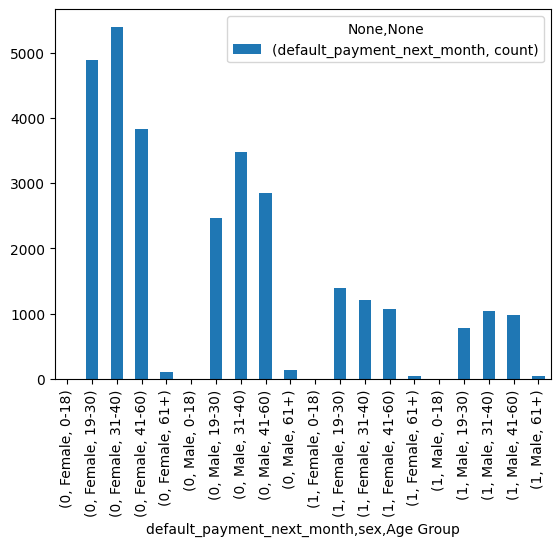

In [144]:
df.groupby(['default_payment_next_month', 'sex', 'Age Group'])[['default_payment_next_month']].agg(['count']).plot(kind='bar')

# 5
### 훈련/테스트 데이터 나누기
* 훈련 데이터 
* 테스트 데이터 
* 검증 데이터

In [78]:
from sklearn.model_selection import train_test_split

X_train, x_test, Y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

x_train, x_val, y_train, y_val = train_test_split(
    X_train, Y_train, test_size=0.2, random_state=42
)

# 6
### 결측값 처리 하기

In [66]:
x_train.isnull().sum()

limit_bal                 0
sex                       0
education               100
marriage                 95
age                      90
payment_status_sep        0
payment_status_aug        0
payment_status_jul        0
payment_status_jun        0
payment_status_may        0
payment_status_apr        0
bill_statement_sep        0
bill_statement_aug        0
bill_statement_jul        0
bill_statement_jun        0
bill_statement_may        0
bill_statement_apr        0
previous_payment_sep      0
previous_payment_aug      0
previous_payment_jul      0
previous_payment_jun      0
previous_payment_may      0
previous_payment_apr      0
dtype: int64

In [79]:
x_train.dropna(inplace=True)
y_train = y_train.loc[x_train.index, :]

x_test.dropna(inplace=True)
y_test = y_test.loc[x_test.index, :]


x_val.dropna(inplace=True)
y_val = y_val.loc[x_val.index, :]


# 7
### 범주형 변수 인코딩

In [71]:
pd.set_option('display.max_columns', None)

In [80]:
x_train = pd.get_dummies(x_train, columns=['sex', 'education', 'marriage', 'payment_status_sep', 'payment_status_aug',
       'payment_status_jul', 'payment_status_jun', 'payment_status_may',
       'payment_status_apr', ], drop_first=False)

# x_train.drop(
#     columns=['sex', 'education', 'marriage',], inplace=True
# )
x_train.head(3)

,limit_bal,age,bill_statement_sep,bill_statement_aug,bill_statement_jul,bill_statement_jun,bill_statement_may,bill_statement_apr,previous_payment_sep,previous_payment_aug,previous_payment_jul,previous_payment_jun,previous_payment_may,previous_payment_apr,sex_Female,sex_Male,education_Graduate school,education_High school,education_Others,education_University,marriage_Married,marriage_Others,marriage_Single,payment_status_sep_Payed duly,payment_status_sep_Payment delayed 1 month,payment_status_sep_Payment delayed 2 months,payment_status_sep_Payment delayed 3 months,payment_status_sep_Payment delayed 4 months,payment_status_sep_Payment delayed 5 months,payment_status_sep_Payment delayed 6 months,payment_status_sep_Payment delayed 7 months,payment_status_sep_Payment delayed 8 months,payment_status_sep_Unknown,payment_status_aug_Payed duly,payment_status_aug_Payment delayed 1 month,payment_status_aug_Payment delayed 2 months,payment_status_aug_Payment delayed 3 months,payment_status_aug_Payment delayed 4 months,payment_status_aug_Payment delayed 5 months,payment_status_aug_Payment delayed 6 months,payment_status_aug_Payment delayed 7 months,payment_status_aug_Payment delayed 8 months,payment_status_aug_Unknown,payment_status_jul_Payed duly,payment_status_jul_Payment delayed 1 month,payment_status_jul_Payment delayed 2 months,payment_status_jul_Payment delayed 3 months,payment_status_jul_Payment delayed 4 months,payment_status_jul_Payment delayed 5 months,payment_status_jul_Payment delayed 6 months,payment_status_jul_Payment delayed 7 months,payment_status_jul_Payment delayed 8 months,payment_status_jul_Unknown,payment_status_jun_Payed duly,payment_status_jun_Payment delayed 1 month,payment_status_jun_Payment delayed 2 months,payment_status_jun_Payment delayed 3 months,payment_status_jun_Payment delayed 4 months,payment_status_jun_Payment delayed 5 months,payment_status_jun_Payment delayed 6 months,payment_status_jun_Payment delayed 7 months,payment_status_jun_Payment delayed 8 months,payment_status_jun_Unknown,payment_status_may_Payed duly,payment_status_may_Payment delayed 2 months,payment_status_may_Payment delayed 3 months,payment_status_may_Payment delayed 4 months,payment_status_may_Payment delayed 5 months,payment_status_may_Payment delayed 6 months,payment_status_may_Payment delayed 7 months,payment_status_may_Payment delayed 8 months,payment_status_may_Unknown,payment_status_apr_Payed duly,payment_status_apr_Payment delayed 2 months,payment_status_apr_Payment delayed 3 months,payment_status_apr_Payment delayed 4 months,payment_status_apr_Payment delayed 5 months,payment_status_apr_Payment delayed 6 months,payment_status_apr_Payment delayed 7 months,payment_status_apr_Payment delayed 8 months,payment_status_apr_Unknown
9922,60000,38.0,59310,60482,58748,49375,38433,38378,2700,0,2100,1600,1600,1600,False,True,True,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True
2156,290000,25.0,305823,303701,296384,248801,241983,230925,15000,10500,10000,15000,7844,23333,True,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True
162,290000,47.0,1234,396,396,792,396,423,396,396,792,0,423,369,False,True,False,True,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,Fa

In [112]:
x_test = pd.get_dummies(x_test, columns=['sex', 'education', 'marriage', 'payment_status_sep', 'payment_status_aug',
       'payment_status_jul', 'payment_status_jun', 'payment_status_may',
       'payment_status_apr', ], drop_first=False)

# x_train.drop(
#     columns=['sex', 'education', 'marriage',], inplace=True
# )
x_test.head(3)

,limit_bal,age,bill_statement_sep,bill_statement_aug,bill_statement_jul,bill_statement_jun,bill_statement_may,bill_statement_apr,previous_payment_sep,previous_payment_aug,previous_payment_jul,previous_payment_jun,previous_payment_may,previous_payment_apr,sex_Female,sex_Male,education_Graduate school,education_High school,education_Others,education_University,marriage_Married,marriage_Others,marriage_Single,payment_status_sep_Payed duly,payment_status_sep_Payment delayed 1 month,payment_status_sep_Payment delayed 2 months,payment_status_sep_Payment delayed 3 months,payment_status_sep_Payment delayed 4 months,payment_status_sep_Payment delayed 5 months,payment_status_sep_Payment delayed 7 months,payment_status_sep_Payment delayed 8 months,payment_status_sep_Unknown,payment_status_aug_Payed duly,payment_status_aug_Payment delayed 1 month,payment_status_aug_Payment delayed 2 months,payment_status_aug_Payment delayed 3 months,payment_status_aug_Payment delayed 4 months,payment_status_aug_Payment delayed 6 months,payment_status_aug_Payment delayed 7 months,payment_status_aug_Unknown,payment_status_jul_Payed duly,payment_status_jul_Payment delayed 1 month,payment_status_jul_Payment delayed 2 months,payment_status_jul_Payment delayed 3 months,payment_status_jul_Payment delayed 4 months,payment_status_jul_Payment delayed 5 months,payment_status_jul_Payment delayed 6 months,payment_status_jul_Payment delayed 7 months,payment_status_jul_Payment delayed 8 months,payment_status_jul_Unknown,payment_status_jun_Payed duly,payment_status_jun_Payment delayed 1 month,payment_status_jun_Payment delayed 2 months,payment_status_jun_Payment delayed 3 months,payment_status_jun_Payment delayed 4 months,payment_status_jun_Payment delayed 5 months,payment_status_jun_Payment delayed 6 months,payment_status_jun_Payment delayed 7 months,payment_status_jun_Unknown,payment_status_may_Payed duly,payment_status_may_Payment delayed 2 months,payment_status_may_Payment delayed 3 months,payment_status_may_Payment delayed 4 months,payment_status_may_Payment delayed 5 months,payment_status_may_Payment delayed 6 months,payment_status_may_Payment delayed 7 months,payment_status_may_Unknown,payment_status_apr_Payed duly,payment_status_apr_Payment delayed 2 months,payment_status_apr_Payment delayed 3 months,payment_status_apr_Payment delayed 4 months,payment_status_apr_Payment delayed 5 months,payment_status_apr_Payment delayed 6 months,payment_status_apr_Payment delayed 7 months,payment_status_apr_Unknown
21567,30000,25.0,26376,27483,28242,16498,16923,17649,1550,1308,1300,700,1000,2000,True,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True
28982,240000,33.0,99938,92104,85194,83021,78556,78495,3500,4200,3600,3000,3000,3000,True,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True
7427,150000,32.0,52582,57496,55705,57210,57084,13194,6395,0,2100,222,1000,650,False,True,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True


In [81]:
x_val = pd.get_dummies(x_val, columns=['sex', 'education', 'marriage', 'payment_status_sep', 'payment_status_aug',
       'payment_status_jul', 'payment_status_jun', 'payment_status_may',
       'payment_status_apr', ], drop_first=False)

# x_train.drop(
#     columns=['sex', 'education', 'marriage',], inplace=True
# )
x_val.head(3)

,limit_bal,age,bill_statement_sep,bill_statement_aug,bill_statement_jul,bill_statement_jun,bill_statement_may,bill_statement_apr,previous_payment_sep,previous_payment_aug,previous_payment_jul,previous_payment_jun,previous_payment_may,previous_payment_apr,sex_Female,sex_Male,education_Graduate school,education_High school,education_Others,education_University,marriage_Married,marriage_Others,marriage_Single,payment_status_sep_Payed duly,payment_status_sep_Payment delayed 1 month,payment_status_sep_Payment delayed 2 months,payment_status_sep_Payment delayed 3 months,payment_status_sep_Payment delayed 4 months,payment_status_sep_Payment delayed 5 months,payment_status_sep_Payment delayed 6 months,payment_status_sep_Payment delayed 7 months,payment_status_sep_Payment delayed 8 months,payment_status_sep_Unknown,payment_status_aug_Payed duly,payment_status_aug_Payment delayed 1 month,payment_status_aug_Payment delayed 2 months,payment_status_aug_Payment delayed 3 months,payment_status_aug_Payment delayed 4 months,payment_status_aug_Payment delayed 5 months,payment_status_aug_Payment delayed 6 months,payment_status_aug_Payment delayed 7 months,payment_status_aug_Unknown,payment_status_jul_Payed duly,payment_status_jul_Payment delayed 1 month,payment_status_jul_Payment delayed 2 months,payment_status_jul_Payment delayed 3 months,payment_status_jul_Payment delayed 4 months,payment_status_jul_Payment delayed 5 months,payment_status_jul_Payment delayed 6 months,payment_status_jul_Payment delayed 7 months,payment_status_jul_Unknown,payment_status_jun_Payed duly,payment_status_jun_Payment delayed 2 months,payment_status_jun_Payment delayed 3 months,payment_status_jun_Payment delayed 4 months,payment_status_jun_Payment delayed 5 months,payment_status_jun_Payment delayed 7 months,payment_status_jun_Payment delayed 8 months,payment_status_jun_Unknown,payment_status_may_Payed duly,payment_status_may_Payment delayed 2 months,payment_status_may_Payment delayed 3 months,payment_status_may_Payment delayed 4 months,payment_status_may_Payment delayed 5 months,payment_status_may_Payment delayed 7 months,payment_status_may_Unknown,payment_status_apr_Payed duly,payment_status_apr_Payment delayed 2 months,payment_status_apr_Payment delayed 3 months,payment_status_apr_Payment delayed 4 months,payment_status_apr_Payment delayed 5 months,payment_status_apr_Payment delayed 6 months,payment_status_apr_Payment delayed 7 months,payment_status_apr_Unknown
23266,440000,39.0,58639,66698,43399,44534,25341,20000,30000,2000,24534,5000,20000,20839,True,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True
15748,20000,23.0,15988,16219,17626,18398,19052,15429,794,1674,1446,1100,0,379,True,False,False,False,False,True,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False
16428,50000,47.0,1091,390,1554,390,780,390,390,1554,390,780,0,390,True,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True


In [100]:
set(x_train.columns) ^ set(x_val.columns)

set()

In [114]:
set(x_train.columns) ^ set(x_test.columns)

{'payment_status_apr_Payment delayed 8 months',
 'payment_status_aug_Payment delayed 5 months',
 'payment_status_aug_Payment delayed 8 months',
 'payment_status_jun_Payment delayed 8 months',
 'payment_status_may_Payment delayed 8 months',
 'payment_status_sep_Payment delayed 6 months'}

In [97]:
x_val[['payment_status_apr_Payment delayed 8 months',
 'payment_status_aug_Payment delayed 8 months',
 'payment_status_jul_Payment delayed 8 months',
 'payment_status_jun_Payment delayed 1 month',
 'payment_status_jun_Payment delayed 6 months',
 'payment_status_may_Payment delayed 6 months',
 'payment_status_may_Payment delayed 8 months']] = False

In [115]:
x_test[['payment_status_apr_Payment delayed 8 months',
 'payment_status_aug_Payment delayed 5 months',
 'payment_status_aug_Payment delayed 8 months',
 'payment_status_jun_Payment delayed 8 months',
 'payment_status_may_Payment delayed 8 months',
 'payment_status_sep_Payment delayed 6 months']] = False

In [99]:
x_val.drop(
    columns=[('payment_status_apr_Payment delayed 8 months',
 'payment_status_aug_Payment delayed 8 months',
 'payment_status_jul_Payment delayed 8 months',
 'payment_status_jun_Payment delayed 1 month',
 'payment_status_jun_Payment delayed 6 months',
 'payment_status_may_Payment delayed 6 months',
 'payment_status_may_Payment delayed 8 months')], inplace=True
)

In [105]:
x_train.columns.to_list()
x_val = x_val[x_train.columns.to_list()]

In [116]:
x_train.columns.to_list()
x_test = x_test[x_train.columns.to_list()]

In [ ]:
'''
 1   sex                   29850 non-null  object 
 2   education             29850 non-null  object 
 3   marriage              29850 non-null  object 
 4   age                   29850 non-null  float64
 5   payment_status_sep    30000 non-null  object 
 6   payment_status_aug    30000 non-null  object 
 7   payment_status_jul    30000 non-null  object 
 8   payment_status_jun    30000 non-null  object 
 9   payment_status_may    30000 non-null  object 
 10  payment_status_apr    30000 non-null  object 
'''

# 8
### Decision Tree 모델 만들기 

In [106]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(x_train, y_train)

print(dt.score(x_train, y_train))
print(dt.score(x_val, y_val))

0.9995770776062592
0.7251585623678647


# 9
### confusion matrix 출력하기 

In [117]:
from sklearn.metrics import confusion_matrix

pred = dt.predict(x_test)
confusion_matrix(y_test , pred)

array([[3655,  844],
       [ 753,  505]])

In [118]:
from sklearn.metrics import accuracy_score, precision_score , recall_score , confusion_matrix

def get_clf_eval(y_test , pred):
    confusion = confusion_matrix( y_test, pred)
    accuracy = accuracy_score(y_test , pred)
    precision = precision_score(y_test , pred)
    recall = recall_score(y_test , pred)
    print('오차 행렬')
    print(confusion)
    print('정확도: {0:.4f}, 정밀도: {1:.4f}, 재현율: {2:.4f}'.format(accuracy , precision ,recall))

In [119]:
get_clf_eval(y_test, pred)

오차 행렬
[[3655  844]
 [ 753  505]]
정확도: 0.7226, 정밀도: 0.3744, 재현율: 0.4014


# 10
### GridSearch(10점), Random Search(10점)



In [136]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

params = {'min_impurity_decrease': uniform(0.0001, 0.001),
          'max_depth': randint(20, 50),
          'min_samples_split': randint(2, 25),
          'min_samples_leaf': randint(1, 25),
          }

gs = RandomizedSearchCV(DecisionTreeClassifier(random_state=42), params, 
                        n_iter=100, n_jobs=-1, random_state=42)
gs.fit(x_train, y_train)

/home/dongik/miniconda3/envs/general/lib/python3.11/site-packages/numpy/ma/core.py:2881: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


RandomizedSearchCV(estimator=DecisionTreeClassifier(random_state=42),
                   n_iter=100, n_jobs=-1,
                   param_distributions={'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7f4c84780e50>,
                                        'min_impurity_decrease': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7f4c844acdd0>,
                                        'min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7f4c8462d090>,
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7f4c845d3e10>},
                   random_state=42)

In [138]:
pred = gs.predict(x_test)
# confusion_matrix(y_test , pred)
get_clf_eval(y_test, pred)

오차 행렬
[[4318  181]
 [ 850  408]]
정확도: 0.8209, 정밀도: 0.6927, 재현율: 0.3243
